<a href="https://colab.research.google.com/github/edwinrht/gsti/blob/main/verra_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 2:** Prototype Tool for Mapping Wildfires Using NASA-FIRMS and Earth-Engine API's

## Verra Technology Solutions Job-Inteview-Technical-Exercise

 # Introduction:
 The following script was developed for submission of Task 2 assignment during  employment interview process with Verra Technicial Solutions Team. Task 2 objectives called for development of a digital tool used to assess NASA's Fire Information for Resource Management System (FIRMS) API for available fire alerts.

 Suggested programming languages were cited including Google-Earth-Engine commands written in either JavaScript or Python. This allowed use of the Google Colab environment, preferred for its sharing and notation tools, and the pre-installed earth-engine library and python3 version, as shown in image below.

*   Note, fewer problems are encountered during notebook setup and package installations if run from chrome browser.*


**Figure 1.** Screenshot of local Colab environment

 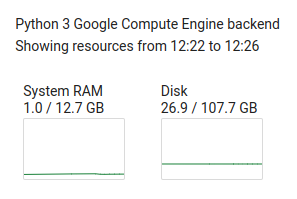


File storage was implemented using the project's public github repository located [here](https://github.com/seamusrobertmurphy/verra-tasks1-2). This respository also stores all data inputs and ouputs from the Task 1 assignment. Since this current notebook was built and hosted on the Colab platform, the repository's version control was instead used in the virtual environment setup of Task 1 tool. Iterations and code edits were committed using Colab-Git widget to enable review of the pipeline's history. Finaly, a mastercopy of this Colab notebook was stored here in its original working directory that is hosted in a personal google drive folder. This was done to allow for quick sharing and secure deploys using the google network.



# 1.1 Data Sources:

Data was sourced from the earth engine (ee) library and imported as a `FeatureCollection` data object using its ee-assighned label 'FIRMS'. Information regaring the dataset's structure, variable labels, and values are stored here in the [Earth Engine Collection Warehouse](https://developers.google.com/earth-engine/datasets/catalog/FIRMS). Hit the 'citation' tab to reveal variable information.  

This 'FIRMS' dataset comprises the same wildfire data used in the [FIRMS digital platform](https://firms.modaps.eosdis.nasa.gov/map/#d:24hrs;@0.0,0.0,3.0z) as its passed through API to API to provide estimates of Near-Real-Time locations of active fires that are  captured, processed, and published on a rolling basis every 3 to 5 five hours from moment of observation at satellite. Note that the NRT dataset is derived from MODIS sensor data that is initally captured at a gridded resolution of 250m2 from the Terra and Aqua satellites and then processed, analyzed and redistributed at a resolution of 1km2 by the LANCE data processing house.

In addition to [NRT](https://www.earthdata.nasa.gov/learn/find-data/near-real-time)-FIRMS data, the LANCE workdesk also produces an Ultra-Real-Time [URT-FIRMS](https://www.earthdata.nasa.gov/learn/articles/firms-urt-data) dataset using automated algorithms and satellite connection networks to broadcast live streams of processed spectral signatures.



To help the user navigate the workflow, the following list of summary steps was drawn from the task's outline document and then reinterpreted after several inital attempts in testing the tool:        

1.   Setup environment & mount drive
2.   Import AOI file of **Spatial Boundary**
3.   Import FIRMS & filter by **Temporal Range**
4.   Map filtered layers over AOI window
5.   Set up **Fire Alerts** showing real-time wildfires
6.   Add option for downloading result rasters



Expect the following code chunk to promt user to authenticate their google-earth-engine account, derive a private token, and paste token into the the in-line box that appears. Follow instructions and links off-page to complete setup.  

#  1. Setup Environment

In [ ]:
!pip install leafmap geemap geopandas
import ee, json, geemap, ipyleaflet, os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.7/213.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.6/717.6 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.0 MB/s eta 0:00:00


In [ ]:
!ee.Authenticate()
ee.Initialize(project='cabin-cffdrs-ee')

/bin/bash: -c: line 2: syntax error: unexpected end of file


RefreshError: ("Failed to retrieve http://metadata.google.internal/computeMetadata/v1/instance/service-accounts/default/?recursive=true from the Google Compute Engine metadata service. Status: 404 Response:\nb''", <google_auth_httplib2._Response object at 0x7a9886bebac0>)

In [ ]:
from google.colab import drive
from google.colab import files
!drive.mount('/content/drive')

/bin/bash: -c: line 1: syntax error near unexpected token `'/content/drive''
/bin/bash: -c: line 1: `drive.mount('/content/drive')'


# 2. Import AOI Data

There are three methods for importing data that seem more user-friendly than others. Uploading local shapefiles can be done using the simple 'drag and drop' method or with use of 'file upload' tab in the top left of this page, both of which load the files into Drive's root directory.

Alternatively, we can prompt the user to upload files interactively using the function that is commented out below: `uploaded = files.upload()`. For these functions to work, the user's personal drive must be mounted to the notebook's environment directory by running the command `!drive.mount('/content/drive')` as has been prepared above.  

For testing these upload functions and subsequent import functions, the AOI shapefile used in this tool should be sourced from here:
https://drive.google.com/drive/folders/1XxciVi_RqrUKzjYUzXL2dvwRQ_15EoxI?usp=drive_link

This sample shapefile provides the correct naming and format used in the code. To test other shapefiles, make sure to rename it as `aoi_filter_small.shp`


In [ ]:
uploaded = files.upload()

The geospatial data package `geopandas` can be used in converting, reviewing, reprojecting, and assigning coordinate reference systems to user's area-of-interest (AOI) files. Once local files have been imported into root drive, the file path and file extension can be entered into geopandas import function as follows.

AOI file is then converted to `Geometry` object and `Feature` object for clipping and mapping purposes.

In [ ]:
import geopandas as gpd
aoi_filter_geopanda = gpd.read_file('/content/aoi_filter_small.shp', crs = 'EPSG:4326')
# Convert AOI to ee.Geometry object for clipping
def shp_to_ee_fmt(geodf):
  data = json.loads(geodf.to_json())
  return data['features'][0]['geometry']['coordinates'
  ]
aoi_filter_geometry = ee.Geometry.MultiPolygon(
    shp_to_ee_fmt(aoi_filter_geopanda)
    )

# Convert AOI to ee.Feature object for styling
aoi_filter_feature = ee.FeatureCollection(
    aoi_filter_geometry
    )
aoi_filter_styled = aoi_filter_feature.style(
    color='#e32636',
    fillColor='80FF0000',
    lineType='solid'
    )


DataSourceError: /content/aoi_filter_small.shp: No such file or directory

# 3. Import FIRMS data

Importing FIRMS data requires filtering by time, variables, and values. This is done below using date range with `filterDate`, with `select` and `median`functions.  

In [ ]:
fires_dataset = ee.ImageCollection(
    'FIRMS').filterDate('2023-10-25', '2023-12-01').select('T21').median()
fires_aoi = fires_dataset.clip(
    aoi_filter_geometry
    )

#  4. Map Layers

In [ ]:
# Map all layers
Map = geemap.Map()
Map.add_basemap('SATELLITE')
Map.centerObject(aoi_filter_geometry, zoom=7)
firesVis = {
    'min': 325.0,
    'max': 400.0,
    'palette': [
        'red', 'orange', 'yellow']
    }

Map.addLayer(fires_aoi, firesVis, 'Fires')
Map.addLayer(aoi_filter_styled, {}, opacity=.75)
Map

NameError: name 'geemap' is not defined

#  5.  Setup Fire Alerts

In [ ]:
# Filter to real-time FIRMS image
fires_full = ee.ImageCollection('FIRMS')
fires_active = fires_full.first()
# Map again
Map = geemap.Map()
Map.add_basemap('SATELLITE')
Map.centerObject(aoi_filter_geometry, zoom=9)
Map.addLayer(aoi_filter_styled, {}, opacity=.75)
Map.addLayer(fires_active, {}, 'Active Fires:FIRMS')
Map


Map(center=[50.64749130996149, -120.24938034062717], controls=(WidgetControl(options=['position', 'transparent…

# ⛔ Fire Alert

Active fires have been identified near you.

Review map above showing near-real-time wildfire data.

Sign up here for daily fire alerts in your area: [FIRMS Fire Alerts ](https://firms.modaps.eosdis.nasa.gov/alerts/)


# 6. Download Data

Need to download your results in raster format for local mapping?

Replace folder path with personal drive folder and run code.

In [ ]:
task = ee.batch.Export.image.toDrive(image=fires_aoi,
                                     scale=30,
                                     fileFormat='GeoTIFF',
                                     description='Wildfires_AOI_2023OctDec',
                                     folder='/content/',
                                     maxPixels=1e9)

task.start()